# Monoclonal Antibody (mAb) Titer Prediction on Actual Test Set

**Note:** `datahow_interview_test_targets-TEMPLATE.csv` is a *submission template*, not the real ground truth - every row currently has the same placeholder value (`Y:Titer = 2000`). 

In [1]:
import pathlib

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score

## 1. Load Data and Distribution Analysis

In [2]:
DATA_DIR = "../data"
MODELS_DIR = pathlib.Path("../models")

test_exp = pd.read_csv(f"{DATA_DIR}/test_exp_features.csv", index_col="Exp")
feature_cols = [c for c in test_exp.columns if c != "n_days"]

# to be replaced with the actual test file
targets = pd.read_csv(
    f"{DATA_DIR}/datahow_interview_test_targets-TEMPLATE.csv", index_col="Exp"
)

print("test_exp:", test_exp.shape)
print(f"Using {len(feature_cols)} features")

test_exp: (20, 18)
Using 18 features


Actual Test Target vs. Train Target Distribution Statistics


/var/folders/h0/6hz9lfgx7zx0wp8y0jf80xzr0000gn/T/ipykernel_9524/2520035950.py:17: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  stats.skew(y_test),


,Test Set (N=20),Train Set (N=100)
Count,20.0,100.00
Mean,2000.0,1314.51
Std,0.0,753.09
Min,2000.0,283.46
Median (50%),2000.0,1147.68
Max,2000.0,4822.70
Skewness,NaN,1.88



Distribution Shift Statistical Tests:
  - Kolmogorov-Smirnov (KS) Test: stat = 0.8800, p-value = 1.9313e-14 (Statistically Significant)
  - Mann-Whitney U Test:          stat = 240.0000, p-value = 8.2932e-08 (Statistically Significant)


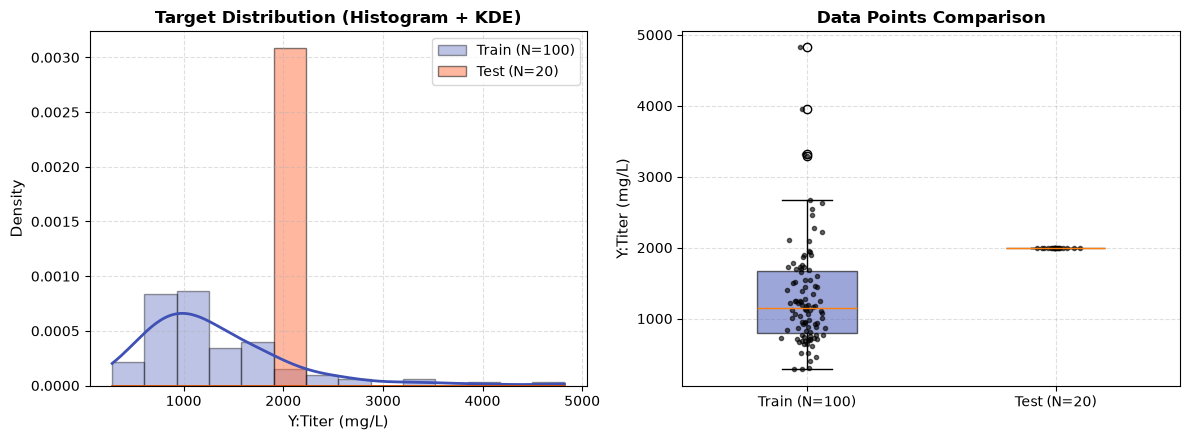

In [3]:
train_targets = pd.read_csv(
    f"{DATA_DIR}/datahow_interview_train_targets.csv", index_col="Exp"
)

y_test = targets["Y:Titer"].dropna()
y_train = train_targets["Y:Titer"].dropna()

stats_df = pd.DataFrame(
    {
        "Test Set (N=20)": [
            len(y_test),
            y_test.mean(),
            y_test.std(),
            y_test.min(),
            y_test.median(),
            y_test.max(),
            stats.skew(y_test),
        ],
        "Train Set (N=100)": [
            len(y_train),
            y_train.mean(),
            y_train.std(),
            y_train.min(),
            y_train.median(),
            y_train.max(),
            stats.skew(y_train),
        ],
    },
    index=[
        "Count",
        "Mean",
        "Std",
        "Min",
        "Median (50%)",
        "Max",
        "Skewness",
    ],
)

print("Actual Test Target vs. Train Target Distribution Statistics")
try:
    display(stats_df.round(2))
except NameError:
    print(stats_df.round(2))

# Distribution shift
ks_stat, ks_p = stats.ks_2samp(y_train, y_test)
mw_stat, mw_p = stats.mannwhitneyu(y_train, y_test)

print()
print("Distribution Shift Statistical Tests:")
print(
    f"  - Kolmogorov-Smirnov (KS) Test: stat = {ks_stat:.4f}, p-value = {ks_p:.4e}"
    f" {'(Statistically Significant)' if ks_p < 0.05 else '(No Significant Shift)'}"
)
print(
    f"  - Mann-Whitney U Test:          stat = {mw_stat:.4f}, p-value = {mw_p:.4e}"
    f" {'(Statistically Significant)' if mw_p < 0.05 else '(No Significant Shift)'}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histogram & KDE Density plot
bins_train = np.linspace(
    min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max()), 15
)

axes[0].hist(
    y_train,
    bins=bins_train,
    density=True,
    alpha=0.4,
    color="#5c6bc0",
    edgecolor="black",
    label="Train (N=100)",
)
axes[0].hist(
    y_test,
    bins=bins_train,
    density=True,
    alpha=0.5,
    color="#ff7043",
    edgecolor="black",
    label="Test (N=20)",
)

# Fit KDE lines
kde_x = np.linspace(
    min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max()), 200
)
kde_train = stats.gaussian_kde(y_train)(kde_x)
kde_test = stats.gaussian_kde(y_test)(kde_x)

axes[0].plot(kde_x, kde_train, color="#3f51b5", linewidth=2)
axes[0].plot(kde_x, kde_test, color="#e65100", linewidth=2)

axes[0].set_title(
    "Target Distribution (Histogram + KDE)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Y:Titer (mg/L)", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

# Box plot
box_data = [y_train, y_test]
box = axes[1].boxplot(
    box_data,
    tick_labels=["Train (N=100)", "Test (N=20)"],
    patch_artist=True,
    widths=0.4,
)

colors = ["#5c6bc0", "#ff7043"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual data points with jitter
np.random.seed(42)
for i, data in enumerate(box_data, start=1):
    jitter = np.random.normal(i, 0.04, size=len(data))
    axes[1].plot(jitter, data, "k.", alpha=0.6, markersize=6)

axes[1].set_title("Data Points Comparison", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Y:Titer (mg/L)", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 2. Load trained models

Load the trained regressors from `models` folder that were fit on the full training set and persisted with `joblib` in `baseline.ipynb`.

In [4]:
model_files = {
    "Linear Regression": "LR.joblib",
    "Multiple Linear Regression Top 5": "MLR_Top5.joblib",
    "Multiple Linear Regression Top 10": "MLR_Top10.joblib",
    "Multiple Linear Regression All Features": "MLR.joblib",
    "Ridge": "Ridge.joblib",
    "PLS (5 comp)": "PLS_5.joblib",
    "RandomForest": "RF.joblib",
    "GradientBoosting": "GradientBoosting.joblib",
    "XGBoost": "XGBoost.joblib",
}
models = {name: joblib.load(MODELS_DIR / fname) for name, fname in model_files.items()}
list(models.keys())

['Linear Regression',
 'Multiple Linear Regression Top 5',
 'Multiple Linear Regression Top 10',
 'Multiple Linear Regression All Features',
 'Ridge',
 'PLS (5 comp)',
 'RandomForest',
 'GradientBoosting',
 'XGBoost']

## 3. Generate predictions and compare againt target reference (template)

- Only the simple `Linear Regression` model was trained on a single feature (`VCD_time_to_peak`)
- Every other model was trained on the full feature set, in the same column order as the training data.

In [5]:
train_exp = pd.read_csv(f"{DATA_DIR}/train_exp_features.csv", index_col="Exp")
_corr_sorted = (
    train_exp[feature_cols]
    .corrwith(train_exp["Y:Titer"])
    .abs()
    .sort_values(ascending=False)
)
best_5_features = _corr_sorted.head(5).index.tolist()
best_10_features = _corr_sorted.head(10).index.tolist()

X_full = test_exp[feature_cols].to_numpy()
X_top5 = test_exp[best_5_features].to_numpy()
X_top10 = test_exp[best_10_features].to_numpy()
X_best = X_top5[:, 0].reshape(-1, 1)

predictions = {}
for name, model in models.items():
    if name == "Linear Regression":
        X_input = X_best
    elif name == "Multiple Linear Regression Top 5":
        X_input = X_top5
    elif name == "Multiple Linear Regression Top 10":
        X_input = X_top10
    else:
        X_input = X_full
    predictions[name] = model.predict(X_input).ravel()

pred_df = pd.DataFrame(predictions, index=test_exp.index)
comparison = pred_df.copy()
comparison["Y:Titer (template)"] = targets["Y:Titer"]
comparison

,Linear Regression,Multiple Linear Regression Top 5,Multiple Linear Regression Top 10,Multiple Linear Regression All Features,Ridge,PLS (5 comp),RandomForest,GradientBoosting,XGBoost,Y:Titer (template)
Exp,,,,,,,,,,
Test Exp 1,2289.087043,2910.697160,2695.487607,2296.752798,2591.753626,2541.328870,2678.196377,2746.885572,2623.430908,2000
Test Exp 2,1592.958634,3024.182043,3189.175972,2916.379963,2788.201633,2822.574409,2675.320493,2506.297058,2214.934814,2000
Test Exp 3,3333.279656,1951.662812,1947.340111,1778.484352,1933.262304,1768.092276,1857.138573,1595.728309,1660.130493,2000
Test Exp 4,1244.894430,2954.428245,2882.670701,2102.615223,2650.990881,2673.056557,1920.299240,1717.054210,1744.676025,2000
Test Exp 5,2637.151247,3202.219843,3103.695949,3272.254652,3160.129814,3181.935297,3162.586506,3025.467084,3047.085938,2000
Test Exp 6,1244.894430,1638.114160,1797.389581,1659.948737,1732.371605,1745.052700,1209.855555,959.935322,1176.250977,2000
Test Exp 7,2637.151247,3956.698491,3800.061720,3539.800263,3472.700440,3529.473205,3123.264864,2534.288660,2868.039795,2000
Test Exp 8,548.766021,2653.401062,2648.357129,1434.399077,2265.844754,2085.011648,1921.273999,1834.054437,1563.777100,2000
Test Exp 9,896.830225,-1297.048856,-1532.805504,-1111.668670,-164.143093,-613.643430,392.609217,422.313399,433.024109,2000


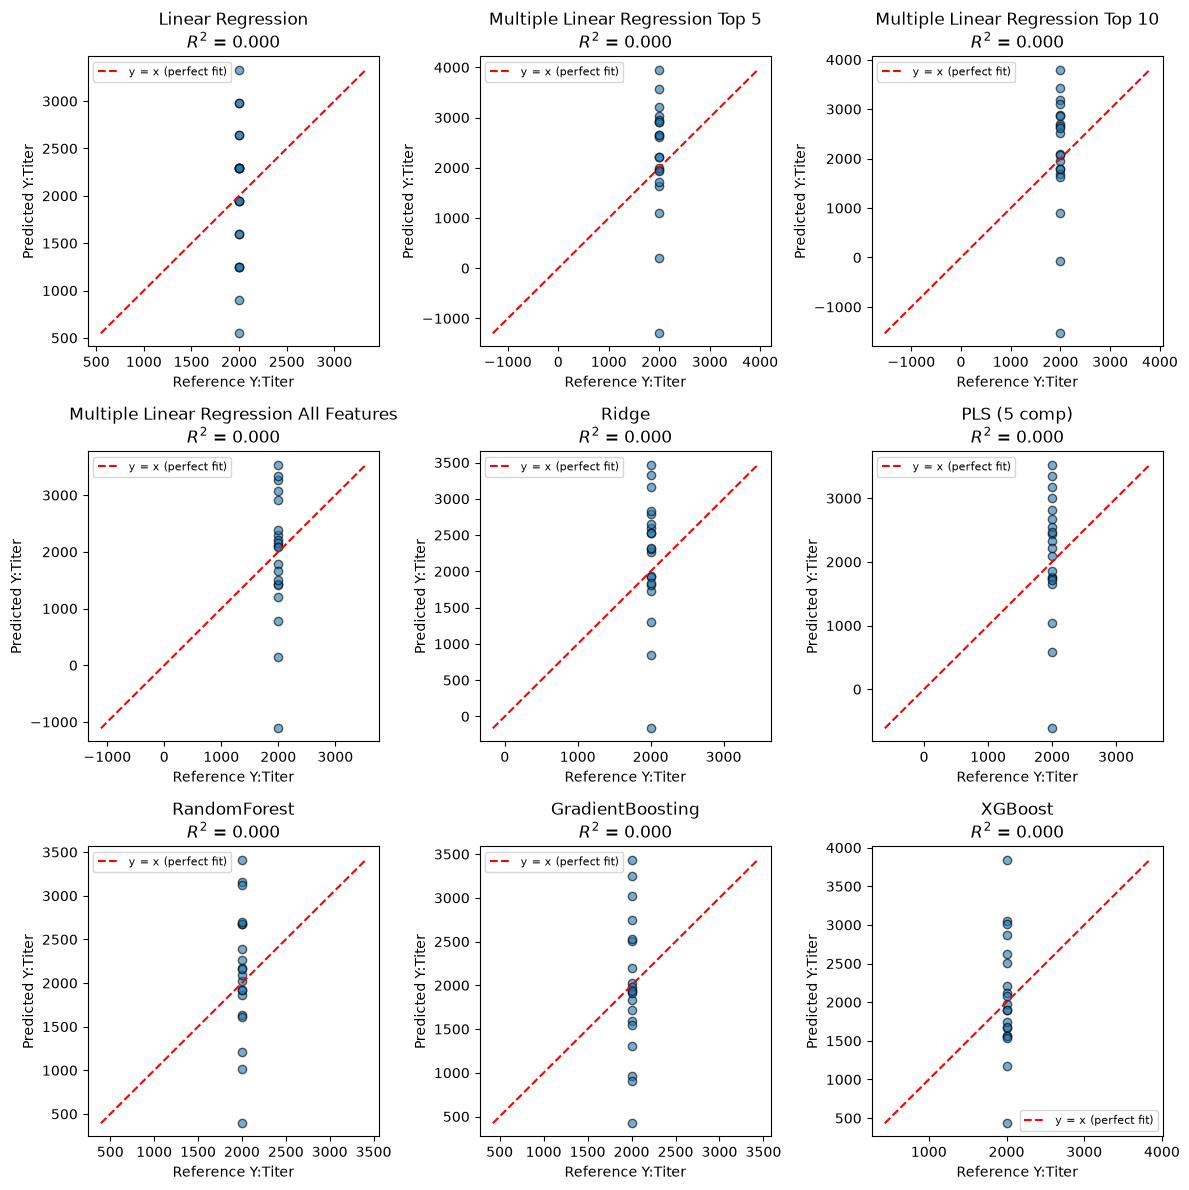

In [6]:
y_true = targets["Y:Titer"].loc[pred_df.index]

n_models = len(pred_df.columns)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, pred_df.columns):
    y_pred = pred_df[name]
    r2 = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolor="k")

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", label="y = x (perfect fit)")

    ax.set_xlabel("Reference Y:Titer")
    ax.set_ylabel("Predicted Y:Titer")
    ax.set_title(f"{name}\n$R^2$ = {r2:.3f}")
    ax.legend(fontsize=8)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
y_true = targets["Y:Titer"].loc[pred_df.index]

metrics = []
for name in pred_df.columns:
    y_pred = pred_df[name]
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    rrmse = rmse / np.mean(y_true)
    metrics.append(
        {
            "model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": rmse,
            "RRMSE": rrmse,
            "R2": r2_score(y_true, y_pred),
        }
    )

print("Model performance on test set (sorted by metrics)")
metrics_df = pd.DataFrame(metrics).sort_values("MAE").reset_index(drop=True)
metrics_df

Model performance on test set (sorted by metrics)


,model,MAE,RMSE,RRMSE,R2
0,XGBoost,559.740845,742.156359,0.371078,0.0
1,RandomForest,564.608907,734.939273,0.367470,0.0
2,GradientBoosting,583.014013,760.621317,0.380311,0.0
3,Linear Regression,591.709147,718.475148,0.359238,0.0
4,Ridge,677.676167,861.346656,0.430673,0.0
5,PLS (5 comp),745.970279,966.801206,0.483401,0.0
6,Multiple Linear Regression All Features,827.469506,1103.580106,0.551790,0.0
7,Multiple Linear Regression Top 5,882.772128,1179.444799,0.589722,0.0
8,Multiple Linear Regression Top 10,888.569417,1211.567362,0.605784,0.0


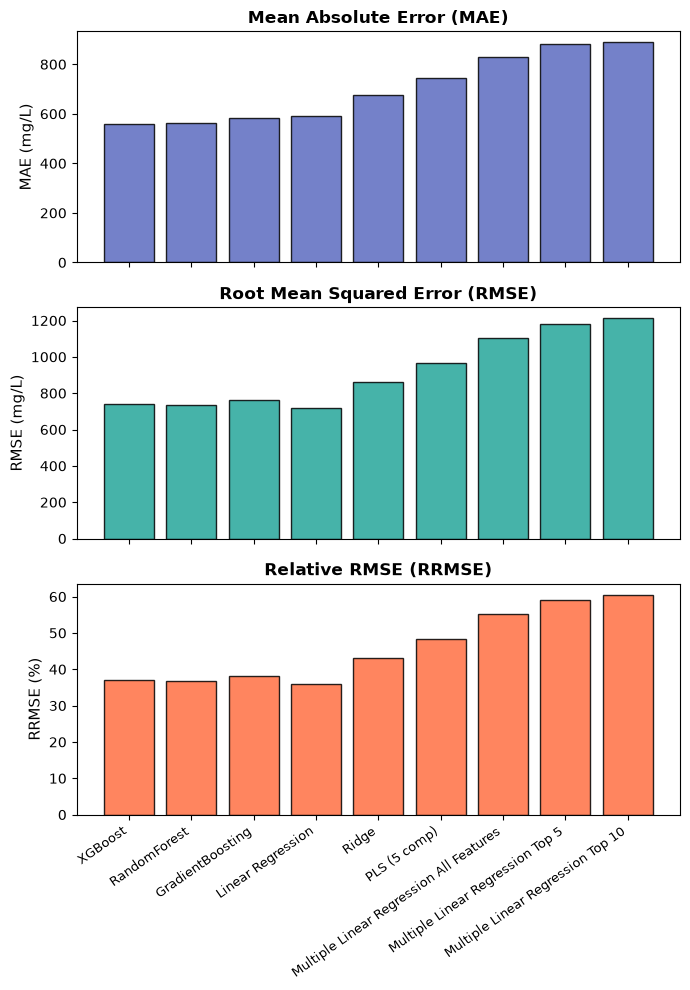

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)

# 1. Mean Absolute Error (MAE)
axes[0].bar(
    metrics_df["model"],
    metrics_df["MAE"],
    color="#5c6bc0",
    edgecolor="black",
    alpha=0.85,
)
axes[0].set_ylabel("MAE (mg/L)", fontsize=11)
axes[0].set_title("Mean Absolute Error (MAE)", fontsize=12, fontweight="bold")
axes[0].set_xticks(range(len(metrics_df)))
axes[0].set_xticklabels(metrics_df["model"], rotation=35, ha="right", fontsize=9.5)

# 2. Root Mean Squared Error (RMSE)
axes[1].bar(
    metrics_df["model"],
    metrics_df["RMSE"],
    color="#26a69a",
    edgecolor="black",
    alpha=0.85,
)
axes[1].set_ylabel("RMSE (mg/L)", fontsize=11)
axes[1].set_title("Root Mean Squared Error (RMSE)", fontsize=12, fontweight="bold")
axes[1].set_xticks(range(len(metrics_df)))
axes[1].set_xticklabels(metrics_df["model"], rotation=35, ha="right", fontsize=9.5)

# 3. Relative RMSE (RRMSE)
axes[2].bar(
    metrics_df["model"],
    metrics_df["RRMSE"] * 100,
    color="#ff7043",
    edgecolor="black",
    alpha=0.85,
)
axes[2].set_ylabel("RRMSE (%)", fontsize=11)
axes[2].set_title("Relative RMSE (RRMSE)", fontsize=12, fontweight="bold")
axes[2].set_xticks(range(len(metrics_df)))
axes[2].set_xticklabels(metrics_df["model"], rotation=35, ha="right", fontsize=9.5)

plt.tight_layout()
plt.show()

For **RMSE** metric, the rule of thumb is that:

- $\text{RMSE} < 0.5 \times \sigma_y$: Excellent model ($R^2 > 0.75$)
- $\text{RMSE} \approx 0.6-0.7 \times \sigma_y$: 
  - Good ensemble model (GradientBoosting, RandomForest, XGBoost)
- $\text{RMSE} \ge \sigma_y$: Model performs worse than simply predicting the dataset mean.

where $\sigma_y$ is the Standard Deviation of the target variable ($y$) 

From research, the rule of thumb for **Relative RMSE (RRMSE)** (%) metric:

- $\text{RRMSE} < 10%$: Excellent accuracy
- $10% \le \text{RRMSE} < 20%$: Good accuracy
- $20% \le \text{RRMSE} \le 30%$: Fair / Acceptable (where tree ensembles fall on this small $N=100$ dataset)
- $\text{RRMSE} > 30%$: Poor accuracy (where unregularized linear models land)